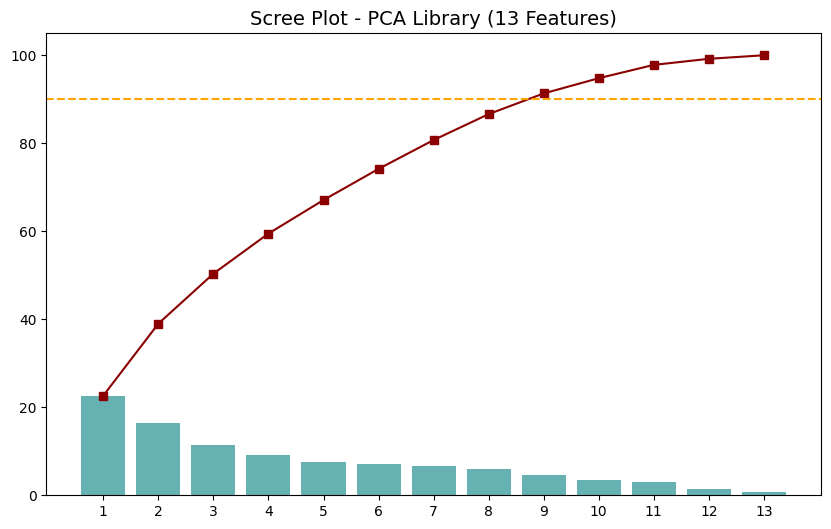

NHẬN XÉT: Giảm từ 13 biến xuống 9 biến chính để giữ >90% thông tin.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Đọc dữ liệu
try:
    df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
except:
    df = pd.read_csv('./clean/hanoi_aqi_cleaned.csv')

# 2. Lọc đúng 13 cột khí tượng (Chữ thường)
target_keywords = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 
                   'precipitation', 'pressure', 'relative_humidity', 
                   'temperature', 'uv_index', 'wind_speed']
df.columns = df.columns.str.strip().str.lower()
cols_found = [c for c in df.columns if any(k == c for k in target_keywords)]
X = df[cols_found].apply(pd.to_numeric, errors='coerce').dropna()

# 3. Chạy PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA().fit(X_scaled)
exp_var = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(exp_var)

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.6, color='teal', label='Riêng lẻ')
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='s', color='darkred', label='Tích lũy')
plt.axhline(y=90, color='orange', linestyle='--')

plt.title(f'Scree Plot - PCA Library ({len(exp_var)} Features)', fontsize=14)
plt.xticks(range(1, len(exp_var) + 1))
plt.show()

pc_90 = np.argmax(cum_var >= 90) + 1
print(f"NHẬN XÉT: Giảm từ {len(cols_found)} biến xuống {pc_90} biến chính để giữ >90% thông tin.")